 # 実践編

## ロジスティック回帰とは

KNNは近所の投票で判定した。

ロジスティック回帰は

「ここから右はウサギ」
「ここから左はモル」

という境界線を学習する。

## シグモイド関数

ロジスティック回帰は計算結果を
0～1の確率に変換する。

$ \sigma(x)=\frac{1}{1+e^{-x}} $

### 確率のイメージ

0.0 ← モル寄り

0.3 ← モルっぽい

0.5 ← 境界

0.8 ← ウサギっぽい

1.0 ← ウサギ確定

ロジスティック回帰では

確率が0.5以上ならウサギ

確率が0.5未満ならモル

と分類する。

## 境界線とは

ロジスティック回帰は

「どこでモルとウサギを分けるか」

という境界線を学習する。

例えば耳の長さだけで判定する場合、

耳が4より小さい → モル

耳が4より大きい → ウサギ

という境界線を作ることができる。

モル      |      ウサギ

● ●       |      ● ●
          4

## 実際に予測する

In [10]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

X = [
    [2, 0.9],
    [3, 1.0],
    [5, 1.5],
    [6, 1.7]
]

# モル=0 ウサギ=1
y = [0, 0, 1, 1]

model = LogisticRegression()
model.fit(X, y)

# 新入り
new_data = [[4, 1.2]]

result = model.predict(new_data)
prob = model.predict_proba(new_data)

if result[0] == 0:
    print("モル")
else:
    print("ウサギ")

print(prob)

モル
[[0.50376113 0.49623887]]


In [11]:
prob = model.predict_proba(new_data)

print(f"モル: {prob[0][0]:.1%}")
print(f"ウサギ: {prob[0][1]:.1%}")

モル: 50.4%
ウサギ: 49.6%


## KNNとの違い

KNN
- 近所の投票で決める

ロジスティック回帰
- 境界線を学習する
- 確率も出せる

## なぜモルになったのか

モル: 50.4%
ウサギ: 49.6%

ほぼ境界線上にいるため、
モデルも判断に迷っている。

ロジスティック回帰は
最終的に確率が50%を超えた方を
予測結果として返す。

---

### 別例 new_data = [[5.5, 1.6]]

In [13]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

X = [
    [2, 0.9],
    [3, 1.0],
    [5, 1.5],
    [6, 1.7]
]

# モル=0 ウサギ=1
y = [0, 0, 1, 1]

model = LogisticRegression()
model.fit(X, y)

# 新入り
new_data = [[5.5, 1.6]]

result = model.predict(new_data)
prob = model.predict_proba(new_data)

if result[0] == 0:
    print("モル")
else:
    print("ウサギ")

print(prob)

ウサギ
[[0.1758819 0.8241181]]


In [14]:
prob = model.predict_proba(new_data)

print(f"モル: {prob[0][0]:.1%}")
print(f"ウサギ: {prob[0][1]:.1%}")

モル: 17.6%
ウサギ: 82.4%


---

## 境界線のイメージ

ロジスティック回帰は
データを分ける境界線を学習する。

境界線の左側はモル、
右側はウサギと判定される。

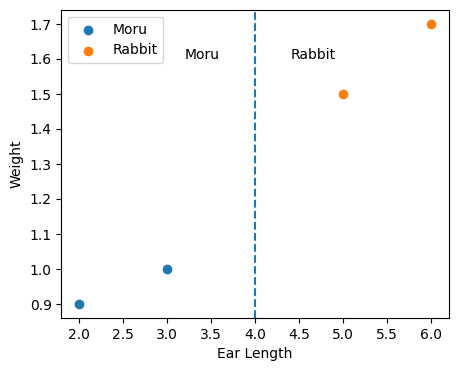

In [15]:
import matplotlib.pyplot as plt

rabbit = [[5,1.5],[6,1.7]]
moru = [[2,0.9],[3,1.0]]

plt.figure(figsize=(5,4))

# モル
plt.scatter(
    [x[0] for x in moru],
    [x[1] for x in moru],
    label="Moru"
)

# ウサギ
plt.scatter(
    [x[0] for x in rabbit],
    [x[1] for x in rabbit],
    label="Rabbit"
)

# 境界線(説明用)
plt.axvline(x=4, linestyle="--")

plt.text(3.2,1.6,"Moru")
plt.text(4.4,1.6,"Rabbit")

plt.xlabel("Ear Length")
plt.ylabel("Weight")
plt.legend()

plt.show()

# まとめ

ロジスティック回帰は

- 確率を計算する
- 境界線を学習する
- predict()で分類できる
- predict_proba()で確率を確認できる

今回の新入り(4,1.2)は

- モル: 50.4%
- ウサギ: 49.6%

であり、ほぼ境界線上だった。